In [1]:
# Install the package if necessary, package repo: https://github.com/pvigier/perlin-numpy
# !pip3 install git+https://github.com/pvigier/perlin-numpy
# !pip3 install seaborn

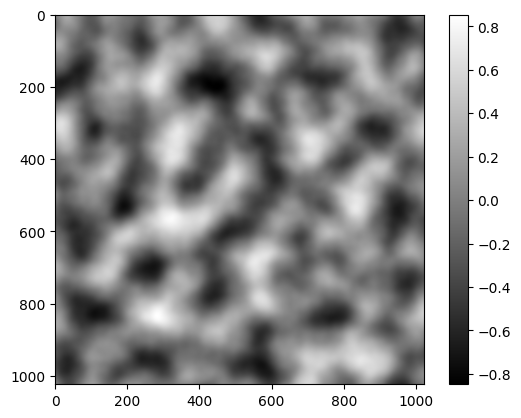

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from colorsys import rgb_to_hls, hls_to_rgb
import numpy as np
import math
import pandas as pd
from perlin_numpy import (
    generate_perlin_noise_2d, generate_fractal_noise_2d
)

#np.random.seed(0)
#noise = generate_perlin_noise_2d((256, 256), (8, 8))
#plt.imshow(noise, cmap='gray', interpolation='lanczos')
#plt.colorbar()

noise = generate_fractal_noise_2d((1024, 1024), (8, 8), 
                                  octaves=8,
                                 persistence=0.2,
                                 lacunarity=2,
                                 #tileable=(True,True)
                                 )
plt.figure()
plt.imshow(noise, cmap='gray', interpolation='lanczos')
plt.colorbar()
plt.show()

In [24]:
def generate_noise(x, y):
    noise = generate_fractal_noise_2d((1024, 1024), (8, 8), 
                                  octaves=8,
                                 persistence=0.2,
                                 lacunarity=2,
                                 #tileable=(True,True)
                                 )
    res = []
    for i in range(y):
        res.append([])
        for j in range(x):
            closest_x = math.floor((i/x)*1024)
            closest_y = math.floor((j/y)*1024)
            res[i].append(noise[closest_x][closest_y])
    #plt.figure()
    #plt.imshow(res, cmap='gray', interpolation='lanczos')
    #plt.colorbar()
    #plt.show()
    return res


In [27]:
def generate_risk_map(risk_density = 0.5, width_height = 100):
    width = width_height
    height = width_height
    noise = generate_noise(width_height, width_height)
    noise = np.array(noise)
    noise += 1
    noise = noise/2
    is_hidden = noise < (1-risk_density)
    for i in range(width):
        for j in range(height):
            noise[i][j] = (noise[i][j] - (1-risk_density) ) / (1- (1-risk_density) )
            if is_hidden[i][j]:
                noise[i][j] = 0
    return noise, is_hidden
        

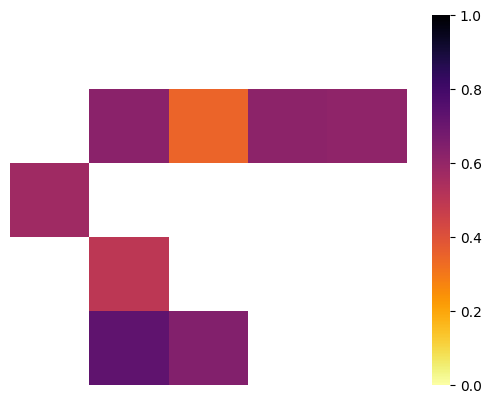

In [37]:
width = 5
height = 5
risk_density = 0.4
width_height_kilometers = 100
cell_distance = width_height_kilometers/width

risk_map, is_risky = generate_risk_map(risk_density = risk_density, width_height = width)
risk_map = risk_map**(1/3)
risk_heatmap = sns.heatmap(risk_map, vmin = 0, vmax = 1, cmap = "inferno_r", mask=is_risky, xticklabels=False, yticklabels=False, linewidths=0)

height_map = generate_noise(width, height)
forest_rate = generate_noise(width, height)
fire_spread_rate = generate_noise(width, height)
is_village = generate_noise(width, height)
vision_bonuses = [[0 for _ in range(width)] for _ in range(height)]
is_buildable_map = [[True for _ in range(width)] for _ in range(height)]
for i in range(width):
    for j in range(height):
        node_height = (1+height_map[i][j])*150
        vision_bonuses[i][j] = int(20*height_map[i][j])
        height_map[i][j] = node_height
        fire_spread_rate[i][j] += 1
        fire_spread_rate[i][j] /= 2
        fire_spread_rate[i][j] *= fire_spread_rate[i][j]
        fire_spread_rate[i][j] *= 3
        forest_rate[i][j] += 1
        forest_rate[i][j] /= 2
        forest_rate[i][j] *= 0.8
        forest_rate[i][j] += 0.2
        if is_village[i][j] > 0.7:
            is_village[i][j] = 1
        else:
            is_village[i][j] = 0
        

In [38]:
lines = []
for i in range(width):
    for j in range(height):
        id = 1 + (i*width) + j
        x_coord = (i/width) * width_height_kilometers
        y_coord = (j/height) * width_height_kilometers
        node_height = int(height_map[i][j])
        risk_status = risk_map[i][j]
        is_buildable = 'buildable' if is_buildable_map[i][j] else 'not_buildable'
        vision_bonus = vision_bonuses[i][j]
        #print(f"""{id} {x_coord:.2f} {y_coord:.2f} {node_height}m {risk_status} {is_buildable} {vision_bonus}%""")
        lines.append([id, x_coord, y_coord, node_height, risk_status, is_buildable, f'{vision_bonus}%', forest_rate[i][j], fire_spread_rate[i][j], is_village[i][j]])
df1 = pd.DataFrame(lines, columns = ['id', 'x_coord', 'y_coord', 'height', 'risk_status', 'is_buildable', 'vision_bonus', 'forest_rate', 'fire_spread_rate', 'is_village'])
df1

,id,x_coord,y_coord,height,risk_status,is_buildable,vision_bonus,forest_rate,fire_spread_rate,is_village
0,1,0.0,0.0,150,0.000000,buildable,0%,0.600000,0.750000,0
1,2,0.0,20.0,171,0.000000,buildable,2%,0.779693,0.606060,0
2,3,0.0,40.0,145,0.000000,buildable,0%,0.670961,0.475607,0
3,4,0.0,60.0,166,0.000000,buildable,2%,0.529612,0.676723,0
4,5,0.0,80.0,147,0.000000,buildable,0%,0.366175,0.505603,0
5,6,20.0,0.0,182,0.000000,buildable,4%,0.366621,0.498489,0
6,7,20.0,20.0,127,0.623441,buildable,-2%,0.423467,0.194788,0
7,8,20.0,40.0,164,0.344089,buildable,1%,0.811370,1.146335,0
8,9,20.0,60.0,213,0.617463,buildable,8%,0.598551,0.437590,0
9,10,20.0,80.0,241,0.610538,buildable,12%,0.613498,2.507285,0


In [39]:
lines = []
lines.append(['UAV_type_A', 5, 1, 100, 5, 6])
lines.append(['UAV_type_B', 10, 0, 100, 5, 6])
lines.append(['Surv_Tower_Basic', 12, 0, 100, 5, 6])
lines.append(['Augmented_Tower', 12, 0, 100, 5, 6])
df2 = pd.DataFrame(lines, columns = ['observer_type', 'vision_radius', 'inventory', 'cost', 'min_vision', 'max_vision'])
df2

,observer_type,vision_radius,inventory,cost,min_vision,max_vision
0,UAV_type_A,5,1,100,5,6
1,UAV_type_B,10,0,100,5,6
2,Surv_Tower_Basic,12,0,100,5,6
3,Augmented_Tower,12,0,100,5,6


In [40]:
def is_covering(source_xy, target_xy, vision_minmax):
    source_x, source_y = source_xy
    target_x, target_y = target_xy
    vision_min, vision_max = vision_minmax
    dist = cell_distance * ((source_x-target_x)**2 + (source_y-target_y)**2)**(1/2)
    
    vision_min *= 1 + (vision_bonuses[source_x][source_y] * 0.01)
    vision_max *= 1 + (vision_bonuses[source_x][source_y] * 0.01)
    print(f'Distance: {dist}')
    if dist < vision_min:
        return 1
    if dist > vision_max:
        return 0
    return (dist-vision_min)/(vision_max-vision_min)
is_covering(source_xy= (2, 2), 
            target_xy= (2, 3), 
            vision_minmax=(3, 4))

Distance: 20.0


0

In [41]:
with pd.ExcelWriter('problem_data_small.xlsx') as writer:
    df1.to_excel(writer, sheet_name="Nodes", index=False)
    df2.to_excel(writer, sheet_name="Parameters", index=False)

In [11]:
def draw_heatmap(freq_map, boolean_map, start_color, end_color, alt_start_color, alt_end_color):
    width, height = len(freq_map), len(freq_map[0])
    color_array = [[ (0, 0, 0) for _ in range(width)] for _ in range(height)]
    for i in range(width):
        for j in range(height):
            if boolean_map[i][j] > 0.5:
                r_diff = (end_color[0]-start_color[0])
                g_diff = (end_color[1]-start_color[1])
                b_diff = (end_color[2]-start_color[2])
                r_gain = r_diff * freq_map[i][j]
                g_gain = g_diff * freq_map[i][j]
                b_gain = b_diff * freq_map[i][j]
                color = (start_color[0] + r_gain, start_color[1] + g_gain, start_color[2] + b_gain)
                color_array[i][j] = color
            else:
                r_diff = (alt_end_color[0]-alt_start_color[0])
                g_diff = (alt_end_color[1]-alt_start_color[1])
                b_diff = (alt_end_color[2]-alt_start_color[2])
                r_gain = r_diff * freq_map[i][j]
                g_gain = g_diff * freq_map[i][j]
                b_gain = b_diff * freq_map[i][j]
                color = (alt_start_color[0] + r_gain, alt_start_color[1] + g_gain, alt_start_color[2] + b_gain)
                color_array[i][j] = color
    plt.figure()
    plt.imshow(color_array)
    plt.show()
    return color_array

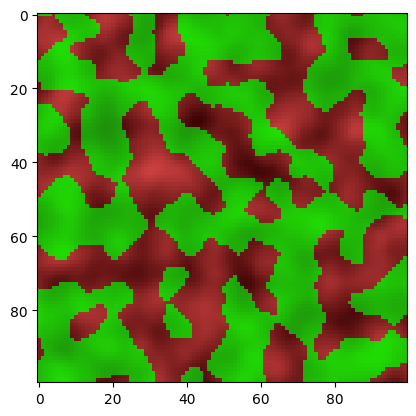

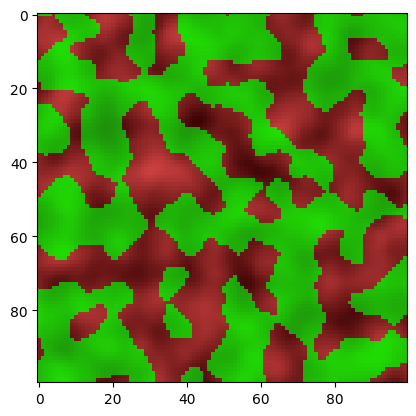

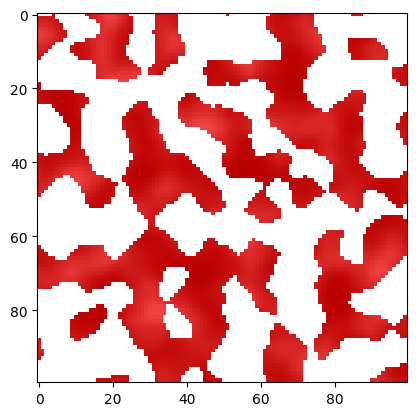

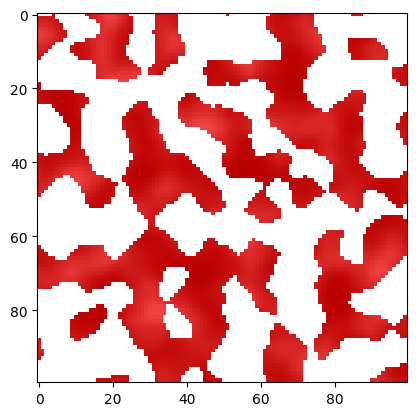

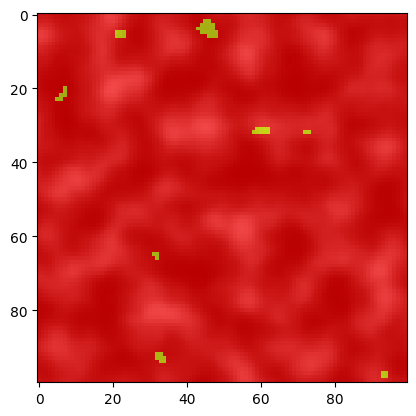

In [10]:
dark_green = (0.118, 0.561, 0.047)
light_green = (0.133, 1, 0)

dark_yellow = (0.635, 0.671, 0.075)
light_yellow = (0.91, 0.961, 0.11)

dark_red = (0.729, 0, 0)
light_red = (0.99, 0.329, 0.329)

dark_blue = (0, 0.094, 0.561)
light_blue = (0.502, 0.588, 1)

very_dark_red = (0.2, 0, 0)

white = (1.0, 1.0, 1.0)

forest_values = draw_heatmap(forest_rate, risk_map, light_red, very_dark_red, light_green, dark_green)
plt.figure()
plt.imshow(forest_values)
#plt.savefig("forest_values-2.svg")
plt.show()

fire_freq = [[fire_spread_rate[i][j]/3 for i in range(width)] for j in range(height)]
fire_heatmap = draw_heatmap(fire_freq, risk_map, dark_red, light_red, white, white)
plt.figure()
plt.imshow(fire_heatmap)
#plt.savefig("fire_heatmap.svg")
plt.show()


a = draw_heatmap(fire_freq, is_village, dark_yellow, light_yellow, dark_red, light_red)


In [12]:
import heapq
from heapq import heappush, heappop
def calculate_burn_value(px, py, spread_time, value_map, response_time = 3):
    # spread map means how long the node takes to spread
    # lots of simplifications but with enough precision they should vanish
    # however, it seems that our fire will spread circularly rather than elliptically
    # because we dont use the fire spread origin info
    width = len(spread_time)
    height = len(spread_time[0])
    pq = []
    heappush(pq, (0, px, py))
    forests_burned = []
    is_visited = [[False for _ in range(width)] for _ in range(height)]
    # bfs time
    while len(pq):
        fire_start_time, x, y = heappop(pq)
        if is_visited[x][y]:
            continue
        is_visited[x][y] = True
        spread_time[x][y] = 1/(1+spread_time[x][y])
        if fire_start_time + spread_time[x][y] > response_time:
            burnt_time = response_time - fire_start_time
            forests_burned.append(value_map[x][y]*(burnt_time/spread_time[x][y]))
            continue
        forests_burned.append(value_map[x][y])
        cur_spread_time = fire_start_time + spread_time[x][y]
        if x > 0:
            heappush(pq, (cur_spread_time, x-1, y))
        if y > 0:
            heappush(pq, (cur_spread_time, x, y-1))
        if x+1 < width:
            heappush(pq, (cur_spread_time, x+1, y))
        if y+1 < height:
            heappush(pq, (cur_spread_time, x, y+1))
    return is_visited

draw_heatmap(forest_rate, 
             calculate_burn_value(15, 5, fire_spread_rate, forest_rate),
             light_green, dark_green, dark_yellow, light_yellow)

fire_spread_copy = fire_spread_rate.copy()
for i in range(3,6):
    fire_spread_copy[13][i] = -0.9
    fire_spread_copy[16][i] = -0.9
    

col_arr = draw_heatmap(forest_rate, 
             calculate_burn_value(15, 5, fire_spread_copy, forest_rate),
             light_green, dark_green, dark_yellow, light_yellow)

for i in range(3, 6):
    col_arr[13][i] = (0, 0, 0)
    col_arr[16][i] = (0, 0, 0)

plt.figure()
plt.imshow(col_arr)
plt.savefig("output.svg")
plt.show()


IndexError: list index out of range

In [12]:
def draw_risk_map(zero_one_map, is_hidden_arr):
    pass

FileNotFoundError: [Errno 2] No such file or directory: '../renders/new_seyrek_fire_map_hot_r.svg'

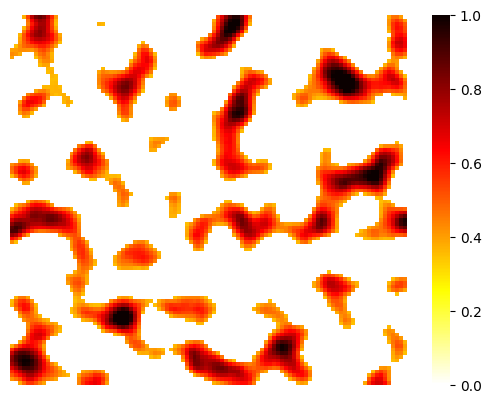

In [14]:
spread_value, is_risky = generate_risk_map(risk_density = 0.41,
                                          width_height = 100)
# hot, autumun_r, autumun, CMRmap, afmhot, gist_heat, inferno, Oranges
spread_value += 0.35
# bu şekilde kalcak
heatmap_first = sns.heatmap(spread_value, vmin = 0, vmax = 1, mask = is_risky, cmap="hot_r", xticklabels=False, yticklabels=False,
                           linewidths=0)
plot = heatmap_first.get_figure()
plot.savefig("../renders/new_seyrek_fire_map_hot_r.svg")
spread_value -= 0.35

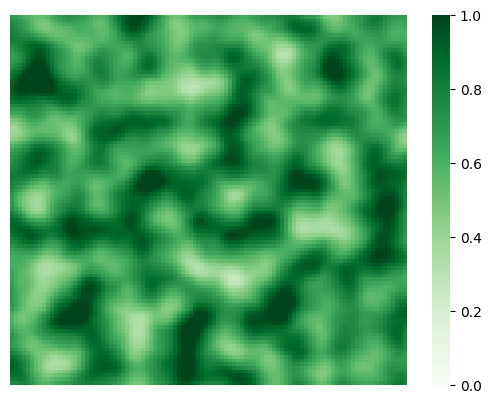

In [36]:
#spread_value -= 0.35
forest_vals, _ = generate_risk_map(risk_density=1.0, width_height=100)
spread_vals, _ = generate_risk_map(risk_density=1.0, width_height=100)

forest_vals = forest_vals + 0.2

# Greens, YlGn, BuGn, summer_r
forest_heatmap = sns.heatmap(forest_vals, vmin = 0, vmax = 1, cmap="Greens", xticklabels=False, yticklabels=False, linewidths=0)
plot = forest_heatmap.get_figure()
plot.savefig("../renders/new_forest_map_Greens.svg")

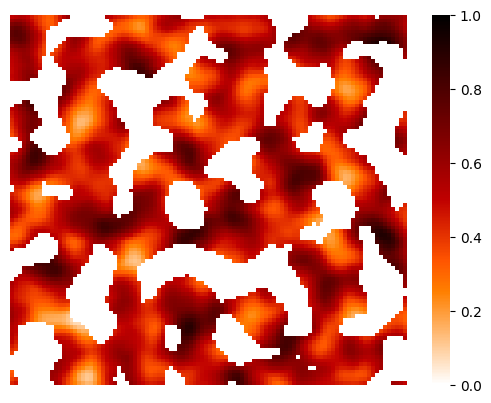

In [37]:
spread_heatmap = sns.heatmap(spread_vals, vmin = 0, vmax = 1, cmap = "gist_heat_r", mask=is_risky, xticklabels=False, yticklabels=False, linewidths=0)
plot = spread_heatmap.get_figure()
plot.savefig("../renders/new_spread_map_gist_heat.svg")

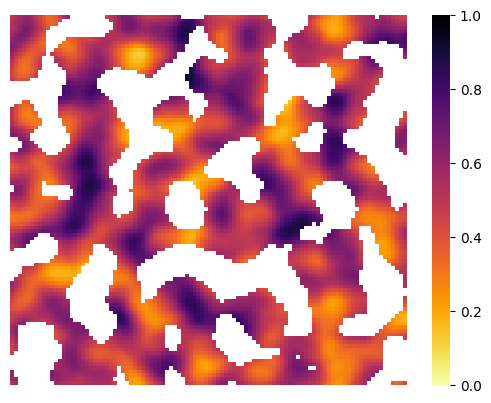

In [38]:
risk_map, _ = generate_risk_map(risk_density=1.0, width_height=100)
#risk_map = risk_map**(1.1)
# yoğunluğu arttırırız
risk_heatmap = sns.heatmap(risk_map, vmin = 0, vmax = 1, cmap = "inferno_r", mask=is_risky, xticklabels=False, yticklabels=False, linewidths=0)
plot = risk_heatmap.get_figure()
plot.savefig("../renders/new_risk_map_inferno.svg")

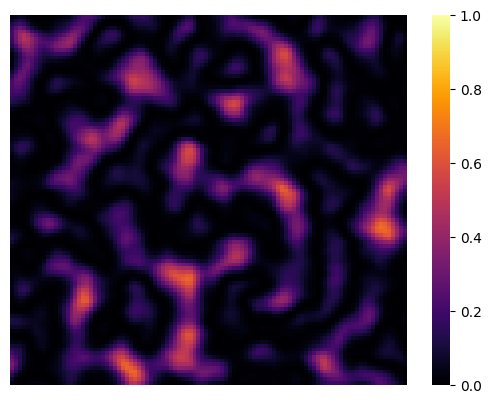

In [18]:
import heapq
from heapq import heappush, heappop
def calculate_burn_value(px, py, spread_time, value_map, risk_status, response_time = 3):
    width = len(spread_time)
    height = len(spread_time[0])
    pq = []
    heappush(pq, (0, px, py))
    forests_burned = []
    is_visited = [[False for _ in range(width)] for _ in range(height)]
    # bfs time
    while len(pq):
        fire_start_time, x, y = heappop(pq)
        if risk_status[x][y]:
            continue
        if is_visited[x][y]:
            continue
        is_visited[x][y] = True
        if fire_start_time + spread_time[x][y] > response_time:
            burnt_time = response_time - fire_start_time
            forests_burned.append(value_map[x][y]*(burnt_time/spread_time[x][y]))
            continue
        forests_burned.append(value_map[x][y])
        cur_spread_time = fire_start_time + spread_time[x][y]
        if x > 0:
            heappush(pq, (cur_spread_time, x-1, y))
        if y > 0:
            heappush(pq, (cur_spread_time, x, y-1))
        if x+1 < width:
            heappush(pq, (cur_spread_time, x+1, y))
        if y+1 < height:
            heappush(pq, (cur_spread_time, x, y+1))
    return np.array(is_visited, dtype=bool)

fire_spread_rate, is_risky = generate_risk_map(risk_density=0.6, width_height=100)
fire_spread_rate *= fire_spread_rate


spread_min = 2
spread_max = 5

spread_time = (fire_spread_rate * (spread_max-spread_min)) + spread_min
# # hot, autumun_r, autumun, CMRmap, afmhot, gist_heat, inferno, Oranges
is_burned = calculate_burn_value(30, 30, spread_time, forest_rate, is_risky, response_time=50)

#sns.heatmap(fire_spread_rate, vmin = 0, vmax = 1, cmap = "hot", mask=is_risky, xticklabels=False, yticklabels=False, linewidths=0)
fg = sns.heatmap(fire_spread_rate, vmin = 0, vmax = 1, cmap = "inferno", xticklabels=False, yticklabels=False, linewidths=0)
plot = fg.get_figure()
plot.savefig("../renders/barrier_original_map.svg")

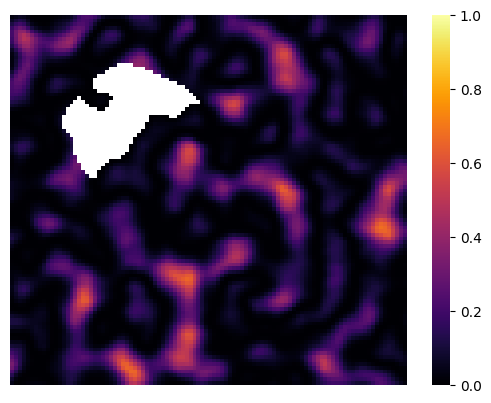

In [19]:
fg = sns.heatmap(fire_spread_rate, vmin = 0, vmax = 1, cmap = "inferno", mask=(is_burned), xticklabels=False, yticklabels=False, linewidths=0)
plot = fg.get_figure()
plot.savefig("../renders/barrier_walless_simul.svg")

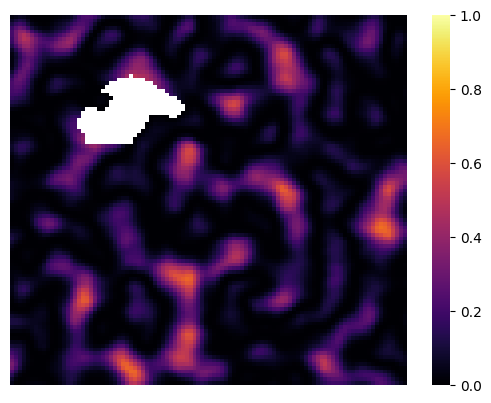

In [20]:
is_not_walled = is_risky.copy()
is_not_walled[35:] = True
is_burned_with_walls = calculate_burn_value(30, 30, spread_time, forest_rate, is_not_walled, response_time=40)
fg = sns.heatmap(fire_spread_rate, vmin = 0, vmax = 1, cmap = "inferno", mask=(is_burned_with_walls), xticklabels=False, yticklabels=False, linewidths=0)
plot = fg.get_figure()
plot.savefig("../renders/barrier_wally_simul.svg")

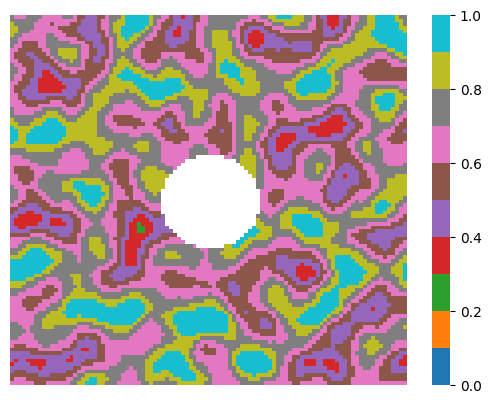

In [21]:
forest_vals, _ = generate_risk_map(risk_density=1.0, width_height=100)
spread_vals, _ = generate_risk_map(risk_density=1.0, width_height=100)

forest_vals = forest_vals + 0.2

is_masked = forest_vals < 0.0

radsq = 160

for i in range(100):
    for j in range(100):
        dist_x = i-50
        dist_y = j-50
        tot_dist = dist_x**2 + dist_y**2
        if tot_dist < radsq:
            is_masked[i][j] = True


# Greens, YlGn, BuGn, summer_r
forest_heatmap = sns.heatmap(forest_vals, vmin = 0, vmax = 1,mask=is_masked , cmap="tab10", xticklabels=False, yticklabels=False, linewidths=0)
plot = forest_heatmap.get_figure()
plot.savefig("../renders/misc.svg")